In [1]:
#config_path = "results/quad_f35_edge_pass_1024_padx2/config.yaml"
import numpy as np; import matplotlib.pyplot as plt # type: ignore
from datetime import datetime
import src.math_tool as mt
import src.img_tool as it
import src.load_config as lc
import src.ASM as ASM
%matplotlib widget
%load_ext autoreload
%autoreload 2
config_path = [ "results/2fz_f30,40b1,1.5_edge_pass_1024_padx2/config.yaml", "results/quad_f35_edge_pass_1024_padx2/config.yaml", "results/HKUST_QR_f5_1024_padx2/config.yaml"]
c = [ lc.load(config_path[i]) for i in range(3) ]
E2 = [ ASM.batch_E2_extract(c[i].Nx, c[i].Ny, c[i].Nz, c[i].path.E2, c[i].sim.z_batch_size) for i in range(3) ]

extracting: 100%|██████████| 250/250 [00:01<00:00, 162.18it/s]


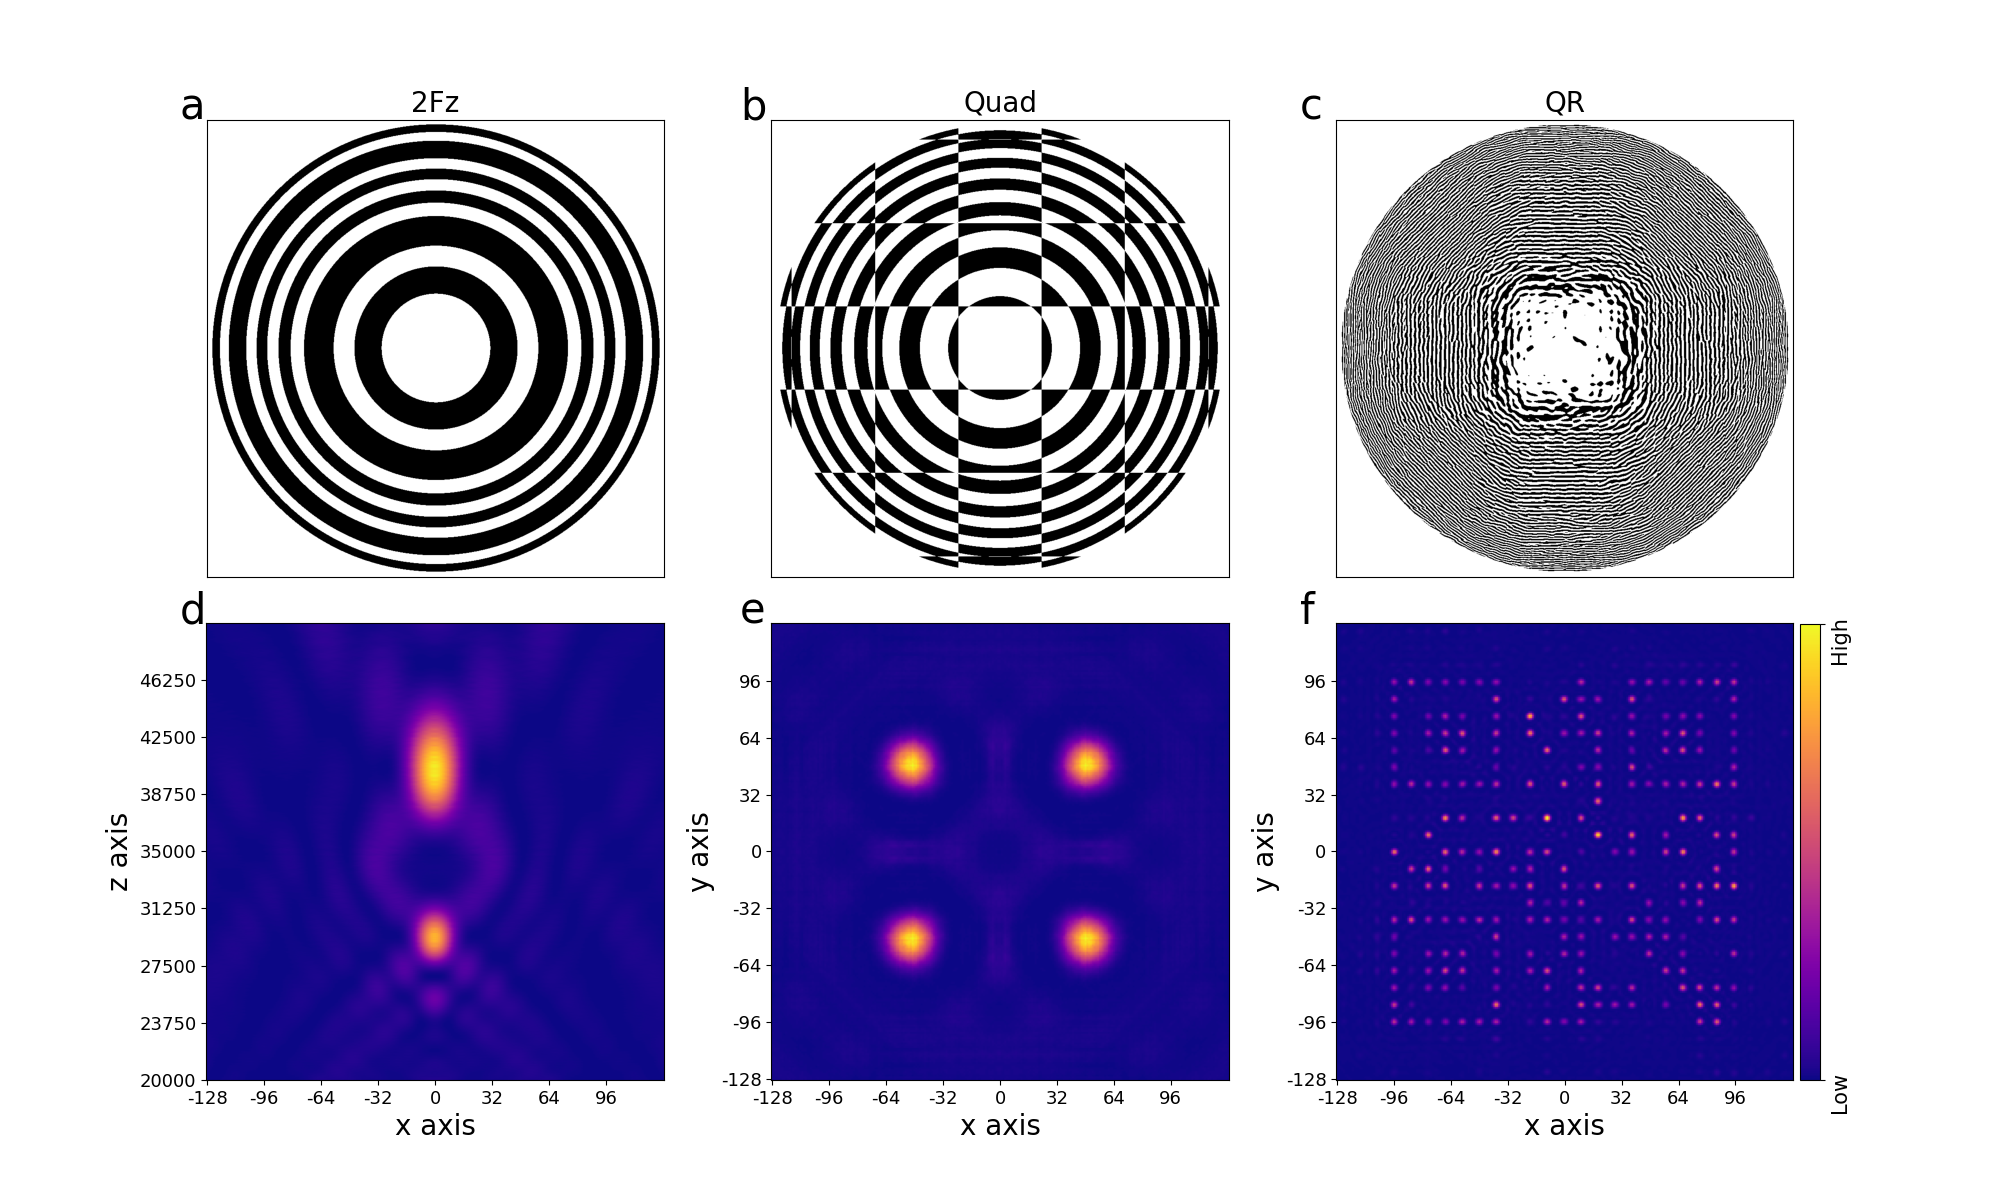

In [73]:
# for QR part
plt.clf()
plt.cla()
plt.rcParams.update({
    'font.size':30,
    'axes.titlesize':20,
    'axes.labelsize':20,
    'ytick.labelsize':13,
    'xtick.labelsize':13,
})
content = [ E2[0][:, 128, :], E2[1][:, :, 500], E2[2][:, :, 500], *[ c[i].aperture[512:-512, 512:-512] for i in range(3)] ]
aspects = [1/11.7, 1, 1, 1, 1, 1]
layout = [[3,4,5], [0,1,2]]
titles = ['x-z plane', 'x-y plane', 'x-y plane', '2Fz', 'Quad', 'QR']
fig, ax = plt.subplot_mosaic(layout, figsize=(20,12))
cmaps = [ *['plasma' for i in range(3)], *['gray' for i in range(3)]]
im = []
for i in range(6):
    im.append(ax[i].imshow(content[i].T, aspect=aspects[i], cmap=cmaps[i]))
    ax[i].invert_yaxis()
    if i < 3:
        if i == 0:
            ax[i].set_xticks(c[i].x_tick_idxs, c[i].xs[c[i].x_tick_idxs].astype(int))
            ax[i].set_yticks(c[i].z_tick_idxs, c[i].zs[c[i].z_tick_idxs].astype(int))
            ax[i].set_xlabel('x axis')
            ax[i].set_ylabel('z axis')
        else:
            ax[i].set_xticks(c[i].x_tick_idxs, c[i].xs[c[i].x_tick_idxs].astype(int))
            ax[i].set_yticks(c[i].y_tick_idxs, c[i].ys[c[i].y_tick_idxs].astype(int))
            ax[i].set_xlabel('x axis')
            ax[i].set_ylabel('y axis')
    else:
        ax[i].set_title(titles[i])
        ax[i].set_xticks([])
        ax[i].set_yticks([])
h1 = 0.9
h2 = 0.48
w0 = 0.09
w1 = w0 + 0
w2 = w0 + 0.28
w3 = w0 + 0.56
fig.text(w1, h1, 'a')
fig.text(w2, h1, 'b')
fig.text(w3, h1, 'c')
fig.text(w1, h2, 'd')
fig.text(w2, h2, 'e')
fig.text(w3, h2, 'f')

plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.2, hspace=0.1)
cbar_ax = fig.add_axes([0.9, 0.1, 0.01, 0.38])
cbar = fig.colorbar(im[2], cax=cbar_ax)
labels = {content[2].max(): 'High', content[2].min(): 'Low'}
cbar.set_ticks(list(labels.keys()))
cbar.ax.set_yticklabels([labels[i] for i in labels.keys()], rotation=90, fontsize=15)
plt.savefig(f'combined_focus.png', bbox_inches='tight')
plt.show()

In [ ]:
# for QR part
content = QR_focus
plt.clf()
plt.figure(figsize=(10, 8))
plt.imshow(content.T, aspect=1, cmap='plasma')
plt.gca().invert_yaxis()
plt.xticks(c.x_tick_idxs, c.xs[c.x_tick_idxs].astype(int)); plt.yticks(c.y_tick_idxs, c.ys[c.y_tick_idxs].astype(int))
plt.title(f'x-y plane')
cbar = plt.colorbar()
labels = {content.max(): 'High', content.min(): 'Low'}
cbar.set_ticks(list(labels.keys()))
cbar.ax.set_yticklabels([labels[i] for i in labels.keys()], rotation=90)
plt.savefig(f'{c.path.results}/focus.png', bbox_inches='tight')
plt.show()